# Day 45 - Gaussian Process Regression
**Predicting Air Quality with Uncertainty Quantification**

Gaussian Process Regression goes beyond point predictions - it provides a full probability distribution over possible outcomes. Perfect for air quality forecasting where knowing the uncertainty helps make safer decisions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [3]:
# Load Beijing PM2.5 Air Quality Dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv"

df = pd.read_csv(url)

In [4]:
print(df.head())

   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0


In [5]:
print(df.describe())

# Drop missing values and select relevant features
df = df.dropna()

                 No          year         month           day          hour  \
count  43824.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean   21912.500000   2012.000000      6.523549     15.727820     11.500000   
std    12651.043435      1.413842      3.448572      8.799425      6.922266   
min        1.000000   2010.000000      1.000000      1.000000      0.000000   
25%    10956.750000   2011.000000      4.000000      8.000000      5.750000   
50%    21912.500000   2012.000000      7.000000     16.000000     11.500000   
75%    32868.250000   2013.000000     10.000000     23.000000     17.250000   
max    43824.000000   2014.000000     12.000000     31.000000     23.000000   

              pm2.5          DEWP          TEMP          PRES           Iws  \
count  41757.000000  43824.000000  43824.000000  43824.000000  43824.000000   
mean      98.613215      1.817246     12.448521   1016.447654     23.889140   
std       92.050387     14.433440     12.198613    

In [8]:
print(df.describe())

                 No          year         month           day          hour  \
count  41757.000000  41757.000000  41757.000000  41757.000000  41757.000000   
mean   22279.380104   2012.042771      6.513758     15.685514     11.502311   
std    12658.168415      1.415311      3.454199      8.785539      6.924848   
min       25.000000   2010.000000      1.000000      1.000000      0.000000   
25%    11464.000000   2011.000000      4.000000      8.000000      5.000000   
50%    22435.000000   2012.000000      7.000000     16.000000     12.000000   
75%    33262.000000   2013.000000     10.000000     23.000000     18.000000   
max    43824.000000   2014.000000     12.000000     31.000000     23.000000   

              pm2.5          DEWP          TEMP          PRES           Iws  \
count  41757.000000  41757.000000  41757.000000  41757.000000  41757.000000   
mean      98.613215      1.750174     12.401561   1016.442896     23.866747   
std       92.050387     14.433658     12.175215    

In [6]:
# Select features: temperature, pressure, dewpoint, wind speed, cumulated precipitation
features = ['TEMP', 'PRES', 'DEWP', 'Iws', 'Is', 'Ir']
target = 'pm2.5'

X = df[features].values
y = df[target].values

# Take a subset for computational efficiency (GPR is O(n³))
# Use 2500 samples total, then split into train/validation/test
indices = np.random.choice(len(X), size=2500, replace=False)
X = X[indices]
y = y[indices]

# Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

# Standardize features (fit only on training data)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print(f"Dataset shape: {X.shape}")
print(f"Train samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")
print(f"PM2.5 range: [{y.min():.1f}, {y.max():.1f}]")
print(f"Features: {features}")

Dataset shape: (2500, 6)
Train samples: 1750, Validation samples: 375, Test samples: 375
PM2.5 range: [3.0, 802.0]
Features: ['TEMP', 'PRES', 'DEWP', 'Iws', 'Is', 'Ir']


In [ ]:
# Single model configuration: Matérn kernel
kernel_name = 'Matérn'
kernel = C(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0)

print(f"\nTraining GP with {kernel_name} kernel...")

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42,
    normalize_y=False  # Already normalized
)

gp.fit(X_train_scaled, y_train_scaled)

# Validation predictions (used for model monitoring)
y_val_pred_scaled, y_val_std_scaled = gp.predict(X_val_scaled, return_std=True)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).ravel()
y_val_std = y_val_std_scaled * scaler_y.scale_[0]

val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

validation_metrics = {
    kernel_name: {
        'rmse': val_rmse,
        'mae': val_mae,
        'r2': val_r2,
        'mean_std': y_val_std.mean()
    }
}

# Test predictions with uncertainty
y_pred_scaled, y_std_scaled = gp.predict(X_test_scaled, return_std=True)

# Transform back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_std = y_std_scaled * scaler_y.scale_[0]

models = {kernel_name: gp}
predictions = {kernel_name: y_pred}
uncertainties = {kernel_name: y_std}
best_model_name = kernel_name

print(f"Optimized kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood(gp.kernel_.theta):.2f}")
print(f"Validation RMSE: {val_rmse:.2f} μg/m³")
print(f"Using single model: {best_model_name}")


Training GP with RBF kernel...
Optimized kernel: 0.712**2 * RBF(length_scale=1.4) + WhiteKernel(noise_level=0.662)
Log-marginal-likelihood: -2181.79
Validation RMSE: 75.56 μg/m³

Training GP with Matérn kernel...
Optimized kernel: 0.793**2 * Matern(length_scale=2.38, nu=1.5) + WhiteKernel(noise_level=0.653)
Log-marginal-likelihood: -2177.71
Validation RMSE: 75.15 μg/m³

Training GP with RationalQuadratic kernel...
Optimized kernel: 0.816**2 * RationalQuadratic(alpha=0.533, length_scale=1.62) + WhiteKernel(noise_level=0.656)
Log-marginal-likelihood: -2178.87
Validation RMSE: 75.28 μg/m³

Best model on validation set: Matérn (RMSE=75.15)


In [16]:
# Evaluation (Matérn only)
print("\n" + "="*70)
print("MODEL EVALUATION - Air Quality Prediction (PM2.5)")
print("="*70)
print("Single model: Matérn")

name = best_model_name
y_pred = predictions[name]
y_std = uncertainties[name]

val_rmse = validation_metrics[name]['rmse']
val_mae = validation_metrics[name]['mae']
val_r2 = validation_metrics[name]['r2']

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Calibration: percentage of true values within 1σ and 2σ
within_1sigma = np.mean(np.abs(y_test - y_pred) <= y_std)
within_2sigma = np.mean(np.abs(y_test - y_pred) <= 2*y_std)

print(f"\n{name} Kernel:")
print(f"  Validation -> RMSE: {val_rmse:.2f} μg/m³ | MAE: {val_mae:.2f} μg/m³ | R²: {val_r2:.4f}")
print(f"  Test       -> RMSE: {rmse:.2f} μg/m³")
print(f"               MAE:  {mae:.2f} μg/m³")
print(f"               R²:   {r2:.4f}")
print(f"  Mean uncertainty (±1σ): {y_std.mean():.2f} μg/m³")
print(f"  Calibration (within 1σ): {within_1sigma*100:.1f}% (expect ~68%)")
print(f"  Calibration (within 2σ): {within_2sigma*100:.1f}% (expect ~95%)")

print("\n" + "="*70)


MODEL EVALUATION - Air Quality Prediction (PM2.5)
Single model: Matérn

Matérn Kernel:
  Validation -> RMSE: 75.15 μg/m³ | MAE: 53.85 μg/m³ | R²: 0.3565
  Test       -> RMSE: 77.42 μg/m³
               MAE:  55.00 μg/m³
               R²:   0.3418
  Mean uncertainty (±1σ): 79.94 μg/m³
  Calibration (within 1σ): 78.4% (expect ~68%)
  Calibration (within 2σ): 94.7% (expect ~95%)



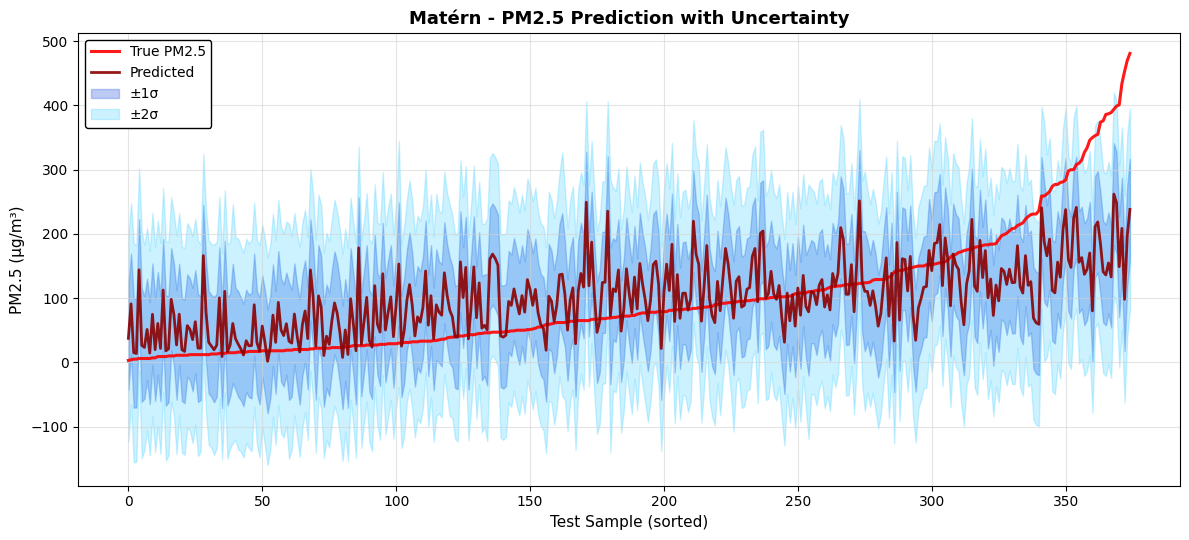

In [15]:
# Visualization (simple style)
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

best_model = best_model_name
y_pred = predictions[best_model]
y_std = uncertainties[best_model]

# Sort by true values for cleaner reading
sort_idx = np.argsort(y_test)
y_test_sorted = y_test[sort_idx]
y_pred_sorted = y_pred[sort_idx]
y_std_sorted = y_std[sort_idx]

# Red curves: true and predicted
ax.plot(y_test_sorted, color='red', linewidth=2.2, alpha=0.9, label='True PM2.5')
ax.plot(y_pred_sorted, color='darkred', linewidth=2.0, alpha=0.9, label='Predicted')

# Blue oscillations: uncertainty bands
x_axis = np.arange(len(y_test_sorted))
ax.fill_between(
    x_axis,
    y_pred_sorted - y_std_sorted,
    y_pred_sorted + y_std_sorted,
    color='royalblue',
    alpha=0.35,
    label='±1σ'
)
ax.fill_between(
    x_axis,
    y_pred_sorted - 2 * y_std_sorted,
    y_pred_sorted + 2 * y_std_sorted,
    color='deepskyblue',
    alpha=0.20,
    label='±2σ'
)

ax.set_title('Matérn - PM2.5 Prediction with Uncertainty', fontsize=13, fontweight='bold', color='black')
ax.set_xlabel('Test Sample (sorted)', fontsize=11, color='black')
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11, color='black')
ax.tick_params(colors='black')
ax.grid(True, color='lightgray', alpha=0.6)

legend = ax.legend(loc='upper left', framealpha=1.0)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')

plt.tight_layout()
plt.show()